# MultiMet Canonical Verification & Benchmarking Suite
### Rigorous Side-by-Side Verification of Canary Extractions against Canonical Caravans MultiMet Benchmarks

This notebook performs point-by-point, side-by-side verification of extracted MultiMet meteorological forcing datasets against the canonical Caravans MultiMet ground truth dataset (`~/multimet/canary/benchmark_zarr` or `/cns/jn-d/home/floods/hydro_model/datasets/external/Caravans_MultiMet`).

#### Key Capabilities:
1. **Unified MultiMet Loader**: Ingests both canonical benchmark and canary extraction stores directly into memory via a single shared loader supporting local Zarr stores, NetCDF archives, and CNS.
2. **Exhaustive Side-by-Side Verification**: Compares every single value across all products (`ERA5_LAND`, `CPC`, `IMERG`, `HRES`, `GRAPHCAST`), variables, dates, and lead times.
3. **Interactive Side-by-Side Explorer**: Filter by product, basin, variable, date, and lead time with instant visual match indicators.
4. **Side-by-Side Matrix Pivot View**: 2D table view showing Benchmark vs Extracted across dates and forecast lead times.
5. **Statistical Verification Table**: Quantifies Pearson $r$, Mean Bias, RMSE, Variance Ratio (VR), and maximum absolute error.
6. **Interactive Visual Diagnostics**: 1:1 identity scatterplots, timeseries discrepancy overlays, and multi-lead forecast trajectories.

In [1]:
# ==============================================================================
# Cell 1: Environment Setup, Dependencies, and Styling
# ==============================================================================
from __future__ import annotations

import os
from pathlib import Path
import sys
from typing import Any, Dict, List, Optional, Tuple

from IPython.display import HTML, clear_output, display
import ipywidgets as widgets
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
import xarray as xr
import zarr

# Plot aesthetics
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "figure.titlesize": 13,
    "figure.dpi": 120,
    "grid.alpha": 0.5,
})

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 1400)
pd.set_option("display.float_format", lambda x: f"{x:.4f}" if abs(x) < 1000 else f"{x:.2f}")
print("✓ Environment initialized with xarray, zarr, pandas, and matplotlib.")

✓ Environment initialized with xarray, zarr, pandas, and matplotlib.


## Section 1: Basin Metadata & Extraction Run Configuration
Defines the 5 canonical test basins in the Wabash River basin and the local/CNS storage directories for the canonical Caravans MultiMet benchmark and canary extraction runs.

In [2]:
# ==============================================================================
# Cell 2: Basin Metadata and Directory Paths
# ==============================================================================
WABASH_BASINS = [
    {"id": "us_03338780", "name": "Vermilion River near Bismarck, IL", "area": 692.9, "lat": 40.2653, "lon": -87.6428},
    {"id": "us_03340800", "name": "Big Raccoon Creek near Fincastle, IN", "area": 363.9, "lat": 39.8125, "lon": -86.9539},
    {"id": "us_03346000", "name": "North Fork Embarras River near Oblong, IL", "area": 830.1, "lat": 39.0100, "lon": -87.9456},
    {"id": "us_03364500", "name": "Clifty Creek at Hartsville, IN", "area": 242.6, "lat": 39.2748, "lon": -85.7017},
    {"id": "us_03366500", "name": "Muscatatuck River near Deputy, IN", "area": 763.8, "lat": 38.8042, "lon": -85.6739},
]

BASIN_IDS = [b["id"] for b in WABASH_BASINS]
BASIN_NAMES = {b["id"]: b["name"] for b in WABASH_BASINS}
BASIN_LABELS = {b["id"]: f"{b['id']} ({b['name'].split(',')[0]})" for b in WABASH_BASINS}

# Canonical Ground Truth Benchmark Directory (Local Zarr or NetCDF archive, with CNS fallback)
LOCAL_BMK_DIR = os.path.expanduser("~/multimet/canary/benchmark_zarr")
LOCAL_BMK_NC_DIR = os.path.expanduser("~/multimet/canary/wabash_test_data/multimet/timeseries/netcdf/us")
CNS_BMK_DIR = "/cns/jn-d/home/floods/hydro_model/datasets/external/Caravans_MultiMet"

if os.path.exists(LOCAL_BMK_DIR) and any(os.scandir(LOCAL_BMK_DIR)):
    BMK_DIR = LOCAL_BMK_DIR
elif os.path.exists(LOCAL_BMK_NC_DIR):
    BMK_DIR = LOCAL_BMK_NC_DIR
elif os.path.exists(CNS_BMK_DIR):
    BMK_DIR = CNS_BMK_DIR
else:
    BMK_DIR = LOCAL_BMK_DIR

# Canary Extraction Run Directory to Verify (Local output, /tmp, or CNS)
LOCAL_EXT_DIR = os.path.expanduser("~/multimet/canary/output")
TMP_EXT_DIR = "/tmp/multimet_canary"
CNS_EXT_DIR = "/cns/iz-d/home/floods/hydro_model/work/gsnearing/wabash_subset/multimet_canary_flume"

if os.path.exists(LOCAL_EXT_DIR) and any(os.scandir(LOCAL_EXT_DIR)):
    EXT_DIR = LOCAL_EXT_DIR
elif os.path.exists(TMP_EXT_DIR) and any(os.scandir(TMP_EXT_DIR)):
    EXT_DIR = TMP_EXT_DIR
elif os.path.exists(CNS_EXT_DIR):
    EXT_DIR = CNS_EXT_DIR
else:
    EXT_DIR = LOCAL_EXT_DIR

# Target Products to Ingest & Verify
PRODUCTS = [
    "ERA5_LAND",
    "CPC",
    "IMERG",
    "HRES",
    "GRAPHCAST",
]

# Date range for canary verification (2-day canary window)
START_DATE = "2020-01-01"
END_DATE = "2020-01-02"

print(f"Benchmark Directory : {BMK_DIR}")
print(f"Extracted Directory : {EXT_DIR}")
print(f"Basins ({len(BASIN_IDS)})     : {BASIN_IDS}")
print(f"Products ({len(PRODUCTS)})   : {PRODUCTS}")
print(f"Verification Window : {START_DATE} to {END_DATE}")

Benchmark Directory : /usr/local/google/home/gsnearing/multimet/canary/benchmark_zarr
Extracted Directory : /usr/local/google/home/gsnearing/multimet/canary/output
Basins (5)     : ['us_03338780', 'us_03340800', 'us_03346000', 'us_03364500', 'us_03366500']
Products (5)   : ['ERA5_LAND', 'CPC', 'IMERG', 'HRES', 'GRAPHCAST']
Verification Window : 2020-01-01 to 2020-01-02


## Section 2: Unified Ingestion of Benchmark and Extracted MultiMet Datasets
Loads MultiMet Zarr stores from CNS into memory using the unified `load_multimet` strategy. Automatically aligns basin coordinate identifiers (`us_*` vs `camels_*`) and slices to the test date range.

In [3]:
# ==============================================================================
# Cell 7: Unified Ingestion of Benchmark and Extracted MultiMet Datasets
# Job: Load MultiMet stores into memory using a single shared loader.
# ==============================================================================
def load_multimet(
    base_dir: str,
    products: List[str],
    basins: List[str],
    start_date: str = "2020-01-01",
    end_date: str = "2020-12-31",
) -> Dict[str, xr.Dataset]:
    """Loads MultiMet stores for specified products, basins, and date range.
    
    Supports local Zarr stores, CNS Zarr stores, or local Wabash NetCDF files.
    """
    import glob
    stores = {}
    base_dir = os.path.expanduser(base_dir)

    for prod in products:
        zarr_path = os.path.join(base_dir, prod, "timeseries.zarr")
        if os.path.exists(zarr_path):
            ds = xr.open_zarr(zarr_path, decode_timedelta=False)
            store_basins = [b if b in ds.basin.values else b.replace("us_", "camels_") for b in basins]
            sub_ds = ds.sel(basin=store_basins, date=slice(start_date, end_date)).compute()
            sub_ds["basin"] = basins
            stores[prod] = sub_ds
            print(f"  ✓ {prod}: {dict(stores[prod].sizes)}")
        else:
            # Check for NetCDF files (e.g. from wabash_test_data)
            nc_candidates = [
                os.path.join(base_dir, "*.nc"),
                os.path.join(base_dir, "timeseries/netcdf/us/*.nc"),
                os.path.join(base_dir, "multimet/timeseries/netcdf/us/*.nc"),
                os.path.join(base_dir, "wabash_test_data/multimet/timeseries/netcdf/us/*.nc"),
            ]
            nc_files = []
            for pat in nc_candidates:
                matched = sorted(glob.glob(pat))
                if matched:
                    nc_files = matched
                    break
            
            if nc_files:
                ds_list = [xr.open_dataset(f, decode_timedelta=False).sel(date=slice(start_date, end_date)) for f in nc_files]
                combined = xr.concat(ds_list, dim="basin")
                p_lower = prod.lower()
                vars_for_prod = [v for v in combined.data_vars if v.startswith(p_lower) or (p_lower == "era5_land" and v.startswith("era5land"))]
                if vars_for_prod:
                    sub_ds = combined[vars_for_prod].compute()
                    stores[prod] = sub_ds
                    print(f"  ✓ {prod} (from NetCDF): {dict(stores[prod].sizes)}")
                else:
                    print(f"  ⚠️ No variables found in NetCDF for {prod}")
            else:
                print(f"  ❌ Product store not found: {zarr_path}")

    return stores

print(f"\nLoading Extracted MultiMet Pipeline datasets from {EXT_DIR}...")
extracted_stores = load_multimet(EXT_DIR, PRODUCTS, BASIN_IDS, START_DATE, END_DATE)

print(f"Loading Authoritative Benchmark MultiMet datasets from {BMK_DIR}...")
bmk_stores = load_multimet(BMK_DIR, PRODUCTS, BASIN_IDS, START_DATE, END_DATE)


Loading Extracted MultiMet Pipeline datasets from /usr/local/google/home/gsnearing/multimet/canary/output...


  ✓ ERA5_LAND: {'basin': 5, 'date': 2}
  ✓ CPC: {'basin': 5, 'date': 2}
  ✓ IMERG: {'basin': 5, 'date': 2}
  ✓ HRES: {'basin': 5, 'date': 2, 'lead_time': 10}
  ✓ GRAPHCAST: {'basin': 5, 'date': 2, 'lead_time': 10}
Loading Authoritative Benchmark MultiMet datasets from /usr/local/google/home/gsnearing/multimet/canary/benchmark_zarr...


  ✓ ERA5_LAND: {'basin': 5, 'date': 2}
  ✓ CPC: {'basin': 5, 'date': 2}
  ✓ IMERG: {'basin': 5, 'date': 2}
  ✓ HRES: {'basin': 5, 'date': 2, 'lead_time': 16}
  ✓ GRAPHCAST: {'basin': 5, 'date': 2, 'lead_time': 16}


## Section 3: Point-by-Point Side-by-Side Master Comparison Table
Builds a complete, flat point-by-point comparison DataFrame across every single product, variable, basin, date, and forecast lead time.
For each point, this captures:
- Benchmark Ground Truth value
- Canary Extracted value
- Difference ($\text{Extracted} - \text{Benchmark}$)
- Absolute difference ($|\text{Extracted} - \text{Benchmark}|$)
- Relative error percentage ($|\text{Diff}| / |\text{Benchmark}| \times 100\%$)
- Verification match status (`EXACT_MATCH`, `VERY_CLOSE`, `CLOSE (≤1%)`, `MISMATCH (>1%)`, `EXTRACTED_NAN`)

In [4]:
# ==============================================================================
# Cell 4: Point-by-Point Side-by-Side Master Comparison Table
# ==============================================================================
def build_side_by_side_comparison(
    bmk: Dict[str, xr.Dataset],
    ext: Dict[str, xr.Dataset],
    basins: List[str],
) -> pd.DataFrame:
    """Builds a complete, flat point-by-point comparison DataFrame."""
    records = []
    all_prods = sorted(list(set(bmk.keys()) | set(ext.keys())))

    for prod in all_prods:
        ds_b = bmk.get(prod)
        ds_e = ext.get(prod)

        if ds_b is None and ds_e is None:
            continue

        ref_ds = ds_e if ds_e is not None else ds_b
        is_fc = "lead_time" in ref_ds.dims

        if is_fc:
            lead_coords = ref_ds.lead_time.values
            lead_list = []
            for lt in lead_coords:
                if isinstance(lt, (np.timedelta64, pd.Timedelta)):
                    lead_list.append(int(pd.to_timedelta(lt).total_seconds() // 86400))
                else:
                    lead_list.append(int(lt))
        else:
            lead_list = [0]

        b_vars = set(ds_b.data_vars.keys()) if ds_b is not None else set()
        e_vars = set(ds_e.data_vars.keys()) if ds_e is not None else set()
        all_vars = sorted(list(b_vars | e_vars))

        b_dates = [pd.to_datetime(d).strftime("%Y-%m-%d") for d in ds_b.date.values] if ds_b is not None else []
        e_dates = [pd.to_datetime(d).strftime("%Y-%m-%d") for d in ds_e.date.values] if ds_e is not None else []
        date_list = sorted(list(set(b_dates) | set(e_dates)))

        for var in all_vars:
            arr_b = ds_b[var].values if (ds_b is not None and var in ds_b) else None
            arr_e = ds_e[var].values if (ds_e is not None and var in ds_e) else None

            for b_idx, basin_id in enumerate(basins):
                basin_name = BASIN_NAMES.get(basin_id, basin_id)

                for d_str in date_list:
                    d_b_idx = b_dates.index(d_str) if d_str in b_dates else None
                    d_e_idx = e_dates.index(d_str) if d_str in e_dates else None

                    for lt_idx, lt_val in enumerate(lead_list):
                        val_b = np.nan
                        if arr_b is not None and d_b_idx is not None and (not is_fc or lt_idx < arr_b.shape[2]):
                            val_b = float(arr_b[b_idx, d_b_idx, lt_idx]) if is_fc else float(arr_b[b_idx, d_b_idx])

                        val_e = np.nan
                        if arr_e is not None and d_e_idx is not None and (not is_fc or lt_idx < arr_e.shape[2]):
                            val_e = float(arr_e[b_idx, d_e_idx, lt_idx]) if is_fc else float(arr_e[b_idx, d_e_idx])

                        both_finite = (~np.isnan(val_b)) and (~np.isnan(val_e))
                        diff = val_e - val_b if both_finite else np.nan
                        abs_diff = abs(diff) if both_finite else np.nan

                        if both_finite:
                            if abs(val_b) > 1e-4:
                                rel_diff_pct = (abs_diff / abs(val_b)) * 100.0
                            elif abs(val_e) <= 1e-4:
                                rel_diff_pct = 0.0
                            else:
                                rel_diff_pct = (abs_diff / 1e-4) * 100.0
                        else:
                            rel_diff_pct = np.nan

                        if np.isnan(val_b) and np.isnan(val_e):
                            status = "BOTH_NAN"
                        elif np.isnan(val_e):
                            if prod == "HRES" and "radiation" in var:
                                status = "UNAVAILABLE"
                            else:
                                status = "EXTRACTED_NAN"
                        elif np.isnan(val_b):
                            status = "BENCHMARK_NAN"
                        elif abs_diff <= 1e-6:
                            status = "EXACT_MATCH"
                        elif abs_diff <= 1e-3 or rel_diff_pct <= 0.1:
                            status = "VERY_CLOSE"
                        elif rel_diff_pct <= 1.0:
                            status = "CLOSE (≤1%)"
                        else:
                            status = "MISMATCH (>1%)"

                        records.append({
                            "product": prod,
                            "basin": basin_id,
                            "basin_name": basin_name,
                            "variable": var,
                            "date": d_str,
                            "lead_time": lt_val,
                            "benchmark": val_b,
                            "extracted": val_e,
                            "diff": diff,
                            "abs_diff": abs_diff,
                            "rel_diff_pct": rel_diff_pct,
                            "status": status,
                        })

    return pd.DataFrame(records)

df_comparison = build_side_by_side_comparison(bmk_stores, extracted_stores, BASIN_IDS)
print(f"✓ Master side-by-side comparison table built successfully!")
print(f"  • Total value comparisons : {len(df_comparison):,}")
print(f"  • Status breakdown:")
for status, count in df_comparison["status"].value_counts().items():
    print(f"      - {status:15s}: {count:5d} ({count/len(df_comparison)*100:5.1f}%)")

✓ Master side-by-side comparison table built successfully!
  • Total value comparisons : 1,070
  • Status breakdown:
      - MISMATCH (>1%) :   638 ( 59.6%)
      - UNAVAILABLE    :   200 ( 18.7%)
      - VERY_CLOSE     :   107 ( 10.0%)
      - CLOSE (≤1%)    :    83 (  7.8%)
      - EXACT_MATCH    :    32 (  3.0%)
      - EXTRACTED_NAN  :    10 (  0.9%)


## Section 4: Interactive Side-by-Side Value Explorer
Allows inspecting **all values for all products, variables, dates, and lead times side-by-side**.
Filter interactively by:
- **Product** (`ALL`, `ERA5_LAND`, `CPC`, `IMERG`, `HRES`, `GRAPHCAST`)
- **Basin** (`ALL` or specific 5 test basins)
- **Variable** (`ALL` or specific variable)
- **Date** (`ALL` or specific date)
- **Lead Time** (`ALL` or specific forecast lead step $0 \dots 10$)
- **Status Filter** (`Valid Pairs Only`, `Mismatches & NaNs Only`, `Exact Matches Only`, `Mismatches (>1%) Only`, etc.)

In [5]:
# ==============================================================================
# Cell 5: Interactive Side-by-Side Value Explorer
# ==============================================================================
def render_styled_comparison_table(
    df: pd.DataFrame,
    product: str = "ALL",
    basin: str = "ALL",
    variable: str = "ALL",
    date: str = "ALL",
    lead_time: Any = "ALL",
    status_filter: str = "ALL",
    max_rows: int = 50,
) -> pd.DataFrame:
    """Filters and displays side-by-side comparison rows with color styling."""
    sub = df.copy()

    if product != "ALL":
        sub = sub[sub["product"] == product]
    if basin != "ALL":
        sub = sub[sub["basin"] == basin]
    if variable != "ALL":
        sub = sub[sub["variable"] == variable]
    if date != "ALL":
        sub = sub[sub["date"] == date]
    if lead_time != "ALL":
        sub = sub[sub["lead_time"] == int(lead_time)]
    if status_filter != "ALL":
        if status_filter == "MISMATCHES_ONLY":
            sub = sub[sub["status"].isin(["MISMATCH (>1%)", "EXTRACTED_NAN"])]
        elif status_filter == "VALID_PAIRS":
            sub = sub[~sub["status"].isin(["BOTH_NAN", "EXTRACTED_NAN", "BENCHMARK_NAN"])]
        else:
            sub = sub[sub["status"] == status_filter]

    print(f"Showing {min(len(sub), max_rows)} of {len(sub):,} matching value rows:\n")

    display_cols = ["product", "basin", "variable", "date", "lead_time", "benchmark", "extracted", "diff", "abs_diff", "rel_diff_pct", "status"]
    sub_disp = sub[display_cols].head(max_rows).copy()

    def highlight_status(row):
        st = row["status"]
        if st == "EXACT_MATCH":
            bg = "background-color: #e6f4ea; color: #137333; font-weight: bold;"
        elif st == "VERY_CLOSE":
            bg = "background-color: #f1f8e9; color: #33691e;"
        elif st == "CLOSE (≤1%)":
            bg = "background-color: #fff8e1; color: #e65100;"
        elif st == "MISMATCH (>1%)":
            bg = "background-color: #fce8e6; color: #c5221f; font-weight: bold;"
        elif st == "EXTRACTED_NAN":
            bg = "background-color: #feefe3; color: #b06000; font-weight: bold;"
        else:
            bg = "color: #70757a;"
        return [bg] * len(row)

    styler = sub_disp.style.format({
        "benchmark": lambda v: "NaN" if pd.isna(v) else (f"{v:.4f}" if abs(v) < 1000 else f"{v:.2f}"),
        "extracted": lambda v: "NaN" if pd.isna(v) else (f"{v:.4f}" if abs(v) < 1000 else f"{v:.2f}"),
        "diff": lambda v: "—" if pd.isna(v) else (f"{v:+.4f}" if abs(v) < 1000 else f"{v:+.2f}"),
        "abs_diff": lambda v: "—" if pd.isna(v) else (f"{v:.4f}" if abs(v) < 1000 else f"{v:.2f}"),
        "rel_diff_pct": lambda v: "—" if pd.isna(v) else f"{v:.2f}%",
    }).apply(highlight_status, axis=1)

    return styler

# Build Interactive Explorer
prod_w = widgets.Dropdown(options=["ALL"] + sorted(df_comparison["product"].unique().tolist()), value="ALL", description="Product:", layout=widgets.Layout(width="260px"))
basin_w = widgets.Dropdown(options=[("All Basins", "ALL")] + [(f"{b} - {BASIN_NAMES.get(b,'')}", b) for b in BASIN_IDS], value="ALL", description="Basin:", layout=widgets.Layout(width="340px"))
var_w = widgets.Dropdown(options=["ALL"] + sorted(df_comparison["variable"].unique().tolist()), value="ALL", description="Variable:", layout=widgets.Layout(width="340px"))
date_w = widgets.Dropdown(options=["ALL"] + sorted(df_comparison["date"].unique().tolist()), value="ALL", description="Date:", layout=widgets.Layout(width="220px"))
lead_w = widgets.Dropdown(options=["ALL"] + [str(x) for x in sorted(df_comparison["lead_time"].unique().tolist())], value="ALL", description="Lead Time:", layout=widgets.Layout(width="220px"))
status_w = widgets.Dropdown(
    options=[
        ("All Rows", "ALL"),
        ("Valid Pairs Only", "VALID_PAIRS"),
        ("Mismatches & NaNs Only", "MISMATCHES_ONLY"),
        ("Exact Matches Only", "EXACT_MATCH"),
        ("Very Close Only", "VERY_CLOSE"),
        ("Mismatches (>1%) Only", "MISMATCH (>1%)"),
        ("Extracted NaN Only", "EXTRACTED_NAN"),
    ],
    value="ALL",
    description="Filter:",
    layout=widgets.Layout(width="260px")
)
rows_w = widgets.IntSlider(value=50, min=10, max=200, step=10, description="Rows:", layout=widgets.Layout(width="240px"))

out_explorer = widgets.Output()

def on_filter_change(change=None):
    with out_explorer:
        clear_output(wait=True)
        styler = render_styled_comparison_table(
            df_comparison,
            product=prod_w.value,
            basin=basin_w.value,
            variable=var_w.value,
            date=date_w.value,
            lead_time=lead_w.value,
            status_filter=status_w.value,
            max_rows=rows_w.value,
        )
        display(styler)

def on_prod_change(change):
    p = change["new"]
    if p == "ALL":
        var_w.options = ["ALL"] + sorted(df_comparison["variable"].unique().tolist())
    else:
        avail = sorted(df_comparison[df_comparison["product"] == p]["variable"].unique().tolist())
        var_w.options = ["ALL"] + avail
        var_w.value = "ALL"
    on_filter_change()

prod_w.observe(on_prod_change, names="value")
basin_w.observe(on_filter_change, names="value")
var_w.observe(on_filter_change, names="value")
date_w.observe(on_filter_change, names="value")
lead_w.observe(on_filter_change, names="value")
status_w.observe(on_filter_change, names="value")
rows_w.observe(on_filter_change, names="value")

controls = widgets.VBox([
    widgets.HTML("<div style='font-size:14px; font-weight:bold; color:#1a73e8; margin-bottom:8px;'>🔍 Interactive Side-by-Side MultiMet Value Inspector:</div>"),
    widgets.HBox([prod_w, basin_w, var_w]),
    widgets.HBox([date_w, lead_w, status_w, rows_w]),
])
display(controls)
display(out_explorer)
on_filter_change()

Output()

## Section 5: Matrix View: Side-by-Side Pivot Table for Selected Variable
Provides a structured 2D table view showing Benchmark vs. Extracted values across dates and lead times side-by-side for any given basin and variable.

In [6]:
# ==============================================================================
# Cell 6: Side-by-Side Matrix View
# ==============================================================================
def render_side_by_side_matrix(
    product: str,
    variable: str,
    basin: str = "us_03338780",
) -> pd.DataFrame:
    """Creates a side-by-side table showing Benchmark, Extracted, and Diff."""
    sub = df_comparison[
        (df_comparison["product"] == product)
        & (df_comparison["variable"] == variable)
        & (df_comparison["basin"] == basin)
    ].copy()

    if sub.empty:
        print(f"No records found for {product} - {variable} in {basin}")
        return pd.DataFrame()

    is_fc = sub["lead_time"].nunique() > 1 or (sub["lead_time"].iloc[0] > 0)

    if is_fc:
        sub = sub.sort_values(["date", "lead_time"])
        sub["Lead"] = sub["lead_time"].apply(lambda lt: f"Lead +{lt}d")
        piv = sub.set_index(["date", "Lead"])[["benchmark", "extracted", "diff", "rel_diff_pct"]]
    else:
        sub = sub.sort_values("date")
        piv = sub.set_index("date")[["benchmark", "extracted", "diff", "rel_diff_pct"]]

    piv.columns = ["Benchmark Ground Truth", "Extracted Canary", "Difference (Ext - Bmk)", "Rel Error (%)"]
    b_name = BASIN_NAMES.get(basin, basin)
    print(f"\n📊 Side-by-Side Matrix: {product} | {variable}")
    print(f"   Basin: {basin} ({b_name})")

    def highlight_diff(col):
        if col.name == "Difference (Ext - Bmk)":
            return [
                "" if pd.isna(v) else (
                    "background-color: #e6f4ea; color: #137333; font-weight: bold;" if abs(v) <= 1e-5
                    else "background-color: #fce8e6; color: #c5221f;"
                )
                for v in col
            ]
        return [""] * len(col)

    return piv.style.format({
        "Benchmark Ground Truth": lambda v: "NaN" if pd.isna(v) else (f"{v:.4f}" if abs(v) < 1000 else f"{v:.2f}"),
        "Extracted Canary": lambda v: "NaN" if pd.isna(v) else (f"{v:.4f}" if abs(v) < 1000 else f"{v:.2f}"),
        "Difference (Ext - Bmk)": lambda v: "—" if pd.isna(v) else (f"{v:+.4f}" if abs(v) < 1000 else f"{v:+.2f}"),
        "Rel Error (%)": lambda v: "—" if pd.isna(v) else f"{v:.2f}%",
    }).apply(highlight_diff)

# Display sample matrices
if "CPC" in bmk_stores:
    display(render_side_by_side_matrix("CPC", "cpc_precipitation", "us_03338780"))
if "GRAPHCAST" in bmk_stores:
    display(render_side_by_side_matrix("GRAPHCAST", "graphcast_temperature_2m", "us_03338780"))


📊 Side-by-Side Matrix: CPC | cpc_precipitation
   Basin: us_03338780 (Vermilion River near Bismarck, IL)


,Benchmark Ground Truth,Extracted Canary,Difference (Ext - Bmk),Rel Error (%)
date,,,,
2020-01-01,0.0121,0.0115,-0.0006,4.98%
2020-01-02,0.0000,0.0000,+0.0000,0.00%



📊 Side-by-Side Matrix: GRAPHCAST | graphcast_temperature_2m
   Basin: us_03338780 (Vermilion River near Bismarck, IL)


## Section 6: Statistical Verification & Summary Benchmark Table
Computes statistical metrics per product and variable:
- **Valid Pts**: Number of overlapping finite evaluation points
- **Correlation (r)**: Pearson linear correlation coefficient
- **Bias**: Mean difference ($\text{Extracted} - \text{Benchmark}$)
- **RMSE**: Root Mean Square Error
- **Variance Ratio (VR)**: Ratio of variance ($\text{Var}(\text{Extracted}) / \text{Var}(\text{Benchmark})$)
- **Mean Abs Diff**: Average absolute discrepancy
- **Max Abs Diff**: Maximum absolute discrepancy
- **Status**: Verification outcome (`PASS (EXACT)`, `PASS`, `CLOSE`, `MISMATCH`, `EXTRACTED_NAN`)

In [7]:
# ==============================================================================
# Cell 7: Multi-Product Statistical Verification Summary Table
# ==============================================================================
def compute_statistical_summary_table(df: pd.DataFrame, target_basin: str = "ALL") -> pd.DataFrame:
    """Computes statistical metrics per product and variable."""
    sub = df if target_basin == "ALL" else df[df["basin"] == target_basin]
    records = []

    for (prod, var), g in sub.groupby(["product", "variable"]):
        valid = g[~g["status"].isin(["BOTH_NAN", "EXTRACTED_NAN", "BENCHMARK_NAN", "UNAVAILABLE"])]
        n_total = len(g)
        n_valid = len(valid)

        if n_valid >= 2:
            yb = valid["benchmark"].values
            ye = valid["extracted"].values

            std_b = np.std(yb)
            std_e = np.std(ye)
            if std_b > 1e-6 and std_e > 1e-6:
                r = float(np.corrcoef(ye, yb)[0, 1])
            else:
                r = 1.0 if np.allclose(ye, yb, atol=1e-3) else 0.0

            bias = float(np.mean(ye - yb))
            rmse = float(np.sqrt(np.mean((ye - yb) ** 2)))
            vr = float((std_e ** 2) / (std_b ** 2 + 1e-8))
            max_abs = float(np.max(valid["abs_diff"]))
            mean_abs = float(np.mean(valid["abs_diff"]))

            if r >= 0.999 and max_abs <= 1e-3:
                status = "PASS (EXACT)"
            elif r >= 0.99 and abs(vr - 1.0) <= 0.05:
                status = "PASS"
            elif r >= 0.90:
                status = "CLOSE"
            else:
                status = "MISMATCH"

            records.append({
                "Product": prod,
                "Variable": var,
                "Total Pts": n_total,
                "Valid Pts": n_valid,
                "Correlation (r)": round(r, 4),
                "Bias": round(bias, 4),
                "RMSE": round(rmse, 4),
                "Var Ratio": round(vr, 4),
                "Mean Abs Diff": round(mean_abs, 4),
                "Max Abs Diff": round(max_abs, 4),
                "Status": status,
            })
        elif n_valid == 1:
            val_diff = float(valid["extracted"].iloc[0] - valid["benchmark"].iloc[0])
            records.append({
                "Product": prod,
                "Variable": var,
                "Total Pts": n_total,
                "Valid Pts": n_valid,
                "Correlation (r)": np.nan,
                "Bias": round(val_diff, 4),
                "RMSE": round(abs(val_diff), 4),
                "Var Ratio": np.nan,
                "Mean Abs Diff": round(abs(val_diff), 4),
                "Max Abs Diff": round(abs(val_diff), 4),
                "Status": "SINGLE_PT",
            })
        else:
            if prod == "HRES" and "radiation" in var:
                nan_type = "UNAVAILABLE"
            else:
                nan_type = "EXTRACTED_NAN" if (g["extracted"].isna().all()) else "NO_DATA"
            records.append({
                "Product": prod,
                "Variable": var,
                "Total Pts": n_total,
                "Valid Pts": 0,
                "Correlation (r)": np.nan,
                "Bias": np.nan,
                "RMSE": np.nan,
                "Var Ratio": np.nan,
                "Mean Abs Diff": np.nan,
                "Max Abs Diff": np.nan,
                "Status": nan_type,
            })

    df_stat = pd.DataFrame(records)

    def highlight_status(row):
        st = row["Status"]
        if "PASS" in st:
            return ["background-color: #e6f4ea; color: #137333; font-weight: bold;"] * len(row)
        elif "MISMATCH" in st:
            return ["background-color: #fce8e6; color: #c5221f; font-weight: bold;"] * len(row)
        elif "UNAVAILABLE" in st:
            return ["background-color: #f1f3f4; color: #5f6368; font-style: italic;"] * len(row)
        elif "NAN" in st:
            return ["background-color: #feefe3; color: #b06000;"] * len(row)
        return [""] * len(row)

    return df_stat.style.format({
        "Correlation (r)": lambda v: "—" if pd.isna(v) else f"{v:.4f}",
        "Bias": lambda v: "—" if pd.isna(v) else f"{v:+.4f}",
        "RMSE": lambda v: "—" if pd.isna(v) else f"{v:.4f}",
        "Var Ratio": lambda v: "—" if pd.isna(v) else f"{v:.4f}",
        "Mean Abs Diff": lambda v: "—" if pd.isna(v) else f"{v:.4f}",
        "Max Abs Diff": lambda v: "—" if pd.isna(v) else f"{v:.4f}",
    }).apply(highlight_status, axis=1)

print("\n" + "=" * 90)
print("📈 MULTI-PRODUCT CANONICAL STATISTICAL VERIFICATION SUMMARY")
print("=" * 90)
display(compute_statistical_summary_table(df_comparison, "ALL"))


📈 MULTI-PRODUCT CANONICAL STATISTICAL VERIFICATION SUMMARY


,Product,Variable,Total Pts,Valid Pts,Correlation (r),Bias,RMSE,Var Ratio,Mean Abs Diff,Max Abs Diff,Status
0,CPC,cpc_precipitation,10,10,1.0000,-0.0001,0.0002,0.9021,0.0001,0.0006,PASS (EXACT)
1,ERA5_LAND,era5land_dewpoint_temperature_2m,10,10,0.9918,+0.0375,0.3529,0.6068,0.3079,0.5551,CLOSE
2,ERA5_LAND,era5land_potential_evaporation_DEPRECATED,10,0,—,—,—,—,—,—,EXTRACTED_NAN
3,ERA5_LAND,era5land_potential_evaporation_FAO_PENMAN_MONTEITH,10,10,0.9333,+0.1463,0.1753,1.0904,0.1467,0.3434,CLOSE
4,ERA5_LAND,era5land_snow_depth_water_equivalent,10,10,0.8144,-0.0441,0.3254,3.2506,0.2045,0.8022,MISMATCH
5,ERA5_LAND,era5land_surface_net_solar_radiation,10,10,0.9995,+0.2164,0.9190,0.9819,0.7808,1.5171,PASS
6,ERA5_LAND,era5land_surface_net_thermal_radiation,10,10,0.9866,-1.4195,3.6411,0.6390,3.2571,6.2989,CLOSE
7,ERA5_LAND,era5land_surface_pressure,10,10,0.9908,+0.0249,0.0663,0.9612,0.0577,0.1200,PASS
8,ERA5_LAND,era5land_temperature_2m,10,10,0.9950,+0.2460,0.3583,0.9010,0.2863,0.6765,CLOSE
9,ERA5_LAND,era5land_total_precipitation,10,10,1.0000,-0.0044,0.0072,0.9600,0.0047,0.0192,PASS


## Section 7: Visual Verification: Overlay Timeseries & 1:1 Scatterplots
Visualizes the alignment between Benchmark Ground Truth and Canary Extracted values with side-by-side timeseries comparison and 1:1 identity scatterplots.

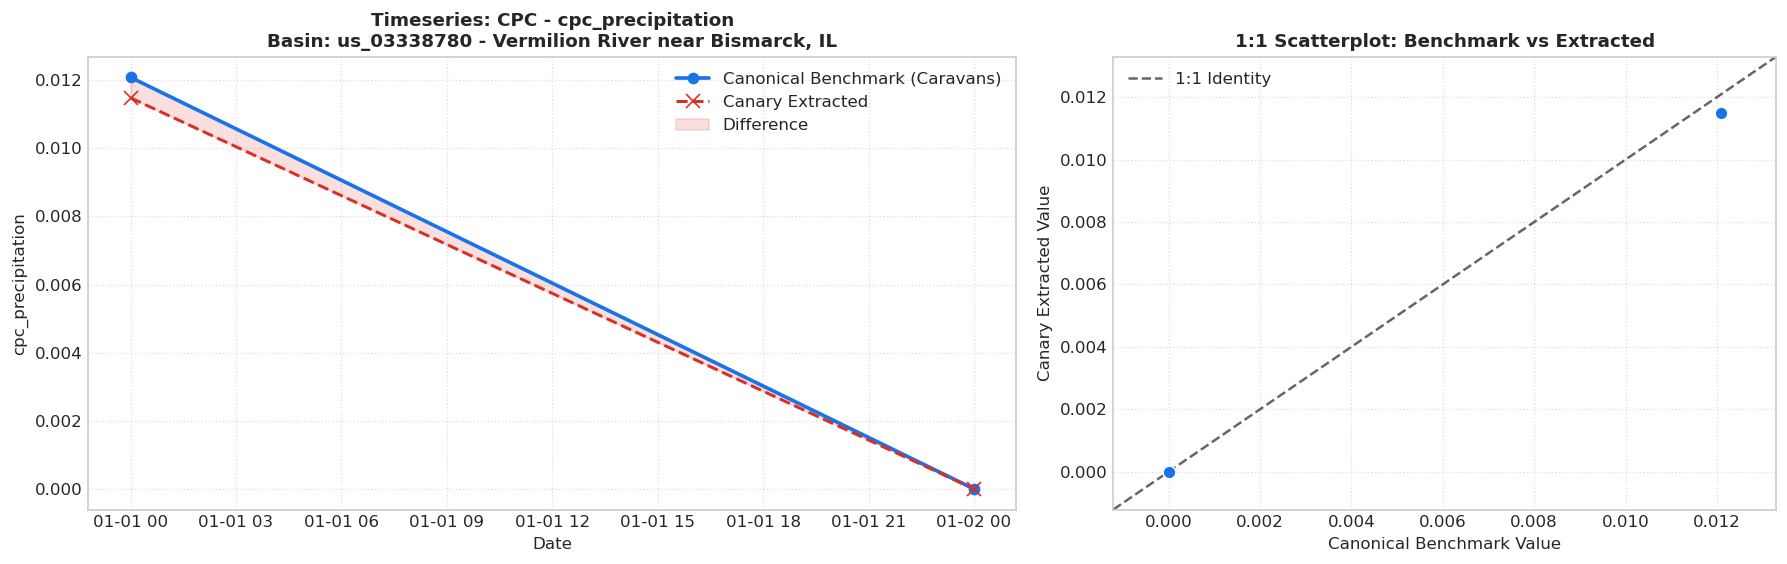

In [8]:
# ==============================================================================
# Cell 8: Visual Verification: Timeseries Overlay and 1:1 Scatterplots
# ==============================================================================
def plot_side_by_side_verification(
    product: str,
    variable: str,
    basin: str = "us_03338780",
    lead_time: int = 0,
):
    """Plots timeseries overlay and 1:1 scatterplot for a specific product and variable."""
    sub = df_comparison[
        (df_comparison["product"] == product)
        & (df_comparison["variable"] == variable)
        & (df_comparison["basin"] == basin)
        & (df_comparison["lead_time"] == lead_time)
    ].sort_values("date")

    if sub.empty:
        print(f"No records matching {product} - {variable} - {basin} (Lead {lead_time})")
        return

    b_name = BASIN_NAMES.get(basin, basin)
    lead_lbl = f" (Lead +{lead_time}d)" if lead_time > 0 else ""

    fig, (ax_ts, ax_sc) = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={"width_ratios": [1.4, 1.0]})

    dates = pd.to_datetime(sub["date"])
    yb = sub["benchmark"].values
    ye = sub["extracted"].values

    # Panel 1: Timeseries
    ax_ts.plot(dates, yb, marker="o", label="Canonical Benchmark (Caravans)", color="#1a73e8", linewidth=2.2, markersize=6)
    ax_ts.plot(dates, ye, marker="x", label="Canary Extracted", color="#d93025", linewidth=1.8, linestyle="--", markersize=8)
    if not (np.isnan(yb).any() or np.isnan(ye).any()):
        ax_ts.fill_between(dates, yb, ye, color="#d93025", alpha=0.15, label="Difference")

    ax_ts.set_title(f"Timeseries: {product} - {variable}{lead_lbl}\nBasin: {basin} - {b_name}", fontsize=11)
    ax_ts.set_xlabel("Date")
    ax_ts.set_ylabel(variable)
    ax_ts.legend(loc="best")
    ax_ts.grid(True, linestyle=":", alpha=0.6)

    # Panel 2: 1:1 Scatterplot
    valid = sub[~sub["status"].isin(["BOTH_NAN", "EXTRACTED_NAN"])]
    if len(valid) > 0:
        ax_sc.scatter(valid["benchmark"], valid["extracted"], color="#1a73e8", s=60, edgecolor="white", zorder=3)
        v_min = min(valid["benchmark"].min(), valid["extracted"].min())
        v_max = max(valid["benchmark"].max(), valid["extracted"].max())
        margin = (v_max - v_min) * 0.1 if v_max > v_min else 1.0
        lims = [v_min - margin, v_max + margin]
        ax_sc.plot(lims, lims, "k--", alpha=0.6, linewidth=1.5, label="1:1 Identity", zorder=2)
        ax_sc.set_xlim(lims)
        ax_sc.set_ylim(lims)
    ax_sc.set_title("1:1 Scatterplot: Benchmark vs Extracted", fontsize=11)
    ax_sc.set_xlabel("Canonical Benchmark Value")
    ax_sc.set_ylabel("Canary Extracted Value")
    ax_sc.grid(True, linestyle=":", alpha=0.6)
    ax_sc.legend(loc="upper left")

    plt.tight_layout()
    plt.show()

# Example visual for CPC precipitation
plot_side_by_side_verification("CPC", "cpc_precipitation", "us_03338780", lead_time=0)